# Banking Dataset - Marketing Targets (Deep Neural Network)

## Overview
This notebook builds an end-to-end deep learning pipeline to predict whether a bank client will **subscribe to a term deposit**, based on the [Banking Dataset - Marketing Targets].

**Workflow:**
1. **Load Libraries** — pandas, numpy, seaborn, scikit-learn, and Keras/TensorFlow.
2. **Load Data** — 45,211 training rows and 4,521 test rows, 17 columns.
3. **Exploratory Data Analysis (EDA)**
   - Data info, missing values, and duplicate checks.
   - Target distribution (imbalanced: ~88% *no* vs ~12% *yes*).
   - Numerical feature distributions, outlier detection (boxplots/IQR).
   - Mixed-type correlation matrix (`dython`).
4. **Preprocessing** — label encoding for categorical features, feature scaling for numerical features.
5. **Modeling** — a deep neural network (Keras `Sequential`) with Dropout and L2 regularization to handle overfitting, trained with class weights to address class imbalance.
6. **Evaluation** — accuracy, F1-score, ROC-AUC, confusion matrix, and ROC curve on the held-out test set.

**Target variable:** `y` — has the client subscribed to a term deposit? (`yes` / `no`)

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/prakharrathi25/banking-dataset-marketing-targets/train.csv
/kaggle/input/datasets/prakharrathi25/banking-dataset-marketing-targets/test.csv


# 1. Load Libraries 

In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder, FunctionTransformer
from sklearn.model_selection import train_test_split, cross_val_score

# Evaluation Metrics
from sklearn.model_selection import learning_curve
from sklearn.metrics import accuracy_score, f1_score,roc_auc_score, confusion_matrix, classification_report, roc_curve

# Neural Network 
from keras.models import Sequential
from keras.layers import Input, Dense , Activation, Dropout
from keras.optimizers import Adam ,RMSprop
from keras import  backend as K
from tensorflow.keras import regularizers
from keras.utils import to_categorical, plot_model


plt.style.use('dark_background')

# 2. Load Data

In [3]:
train_df = pd.read_csv('/kaggle/input/datasets/prakharrathi25/banking-dataset-marketing-targets/train.csv',     sep=';')
test_df = pd.read_csv('/kaggle/input/datasets/prakharrathi25/banking-dataset-marketing-targets/test.csv', sep=';')

print(f"Train shape: {train_df.shape}")
print(f"Test shape: {test_df.shape}")


# using (sep=';') for handling the structure of the CSV file


Train shape: (45211, 17)
Test shape: (4521, 17)


In [4]:
train_df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [5]:
train_df.tail()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
45206,51,technician,married,tertiary,no,825,no,no,cellular,17,nov,977,3,-1,0,unknown,yes
45207,71,retired,divorced,primary,no,1729,no,no,cellular,17,nov,456,2,-1,0,unknown,yes
45208,72,retired,married,secondary,no,5715,no,no,cellular,17,nov,1127,5,184,3,success,yes
45209,57,blue-collar,married,secondary,no,668,no,no,telephone,17,nov,508,4,-1,0,unknown,no
45210,37,entrepreneur,married,secondary,no,2971,no,no,cellular,17,nov,361,2,188,11,other,no


# 3. Explore Data

### Data Information

In [6]:
train_df.describe().T


,count,mean,std,min,25%,50%,75%,max
age,45211.0,40.936210,10.618762,18.0,33.0,39.0,48.0,95.0
balance,45211.0,1362.272058,3044.765829,-8019.0,72.0,448.0,1428.0,102127.0
day,45211.0,15.806419,8.322476,1.0,8.0,16.0,21.0,31.0
duration,45211.0,258.163080,257.527812,0.0,103.0,180.0,319.0,4918.0
campaign,45211.0,2.763841,3.098021,1.0,1.0,2.0,3.0,63.0
pdays,45211.0,40.197828,100.128746,-1.0,-1.0,-1.0,-1.0,871.0
previous,45211.0,0.580323,2.303441,0.0,0.0,0.0,0.0,275.0


In [7]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


### Check Missing Values

In [8]:
train_df.isnull().sum().sort_values(ascending=False)

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

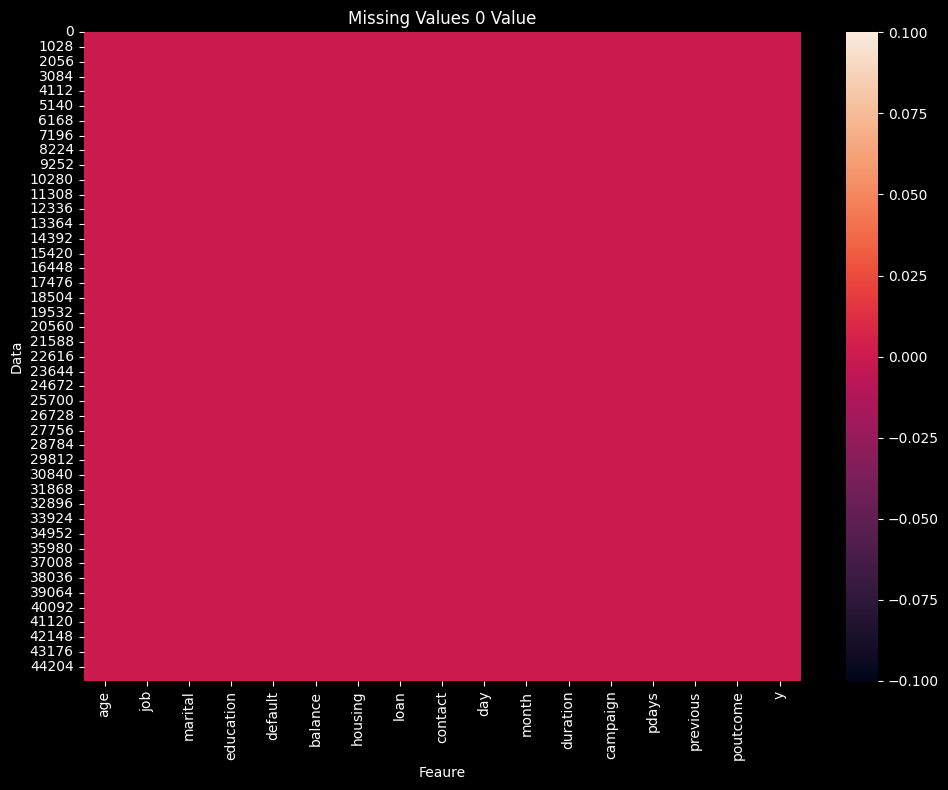

In [9]:
# Visualize Missing Data

plt.figure(figsize = (10,8))
sns.heatmap(train_df.isna(),cbar = True)

plt.xlabel("Feaure")
plt.ylabel("Data")
plt.title(f"Missing Values {train_df.isna().sum().sum()} Value")

plt.tight_layout()
plt.show()


### Check Duplicates

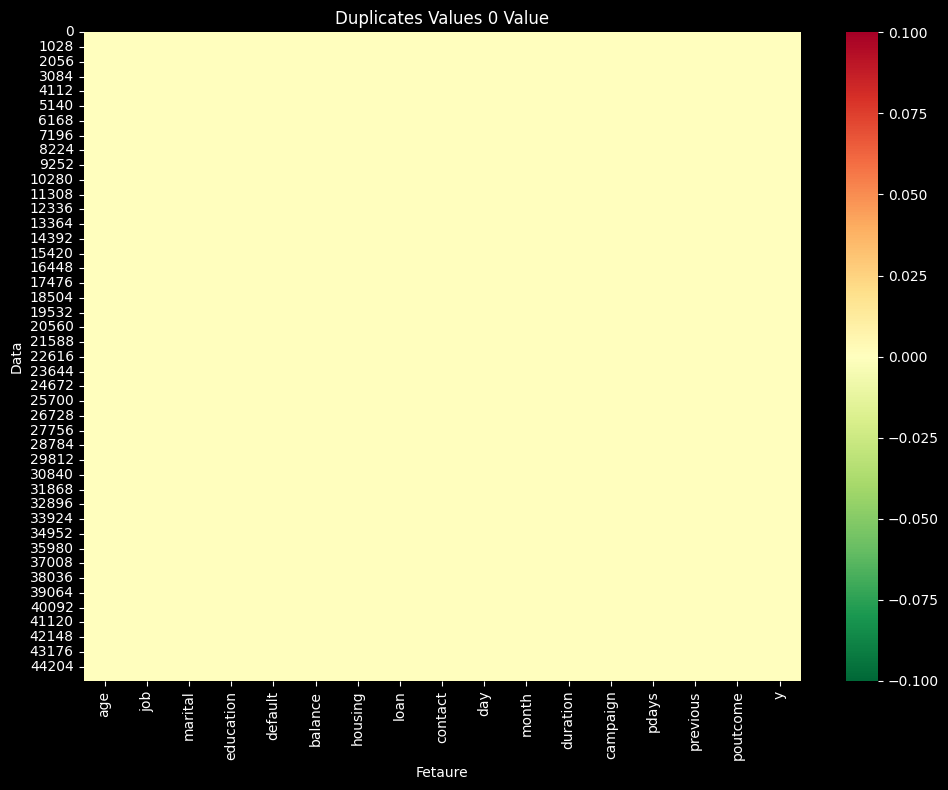

In [10]:
# Visualize Duplicated Data

plt.figure(figsize = (10,8))
duplicated_matrix = np.tile(train_df.duplicated().values.reshape(-1, 1), train_df.shape[1])
sns.heatmap(duplicated_matrix,cbar = True, cmap = 'RdYlGn_r', xticklabels=train_df.columns)

plt.xlabel("Fetaure")
plt.ylabel("Data")
plt.title(f"Duplicates Values {train_df.duplicated().sum()} Value")

plt.tight_layout()
plt.show()


### Check Target Distribution

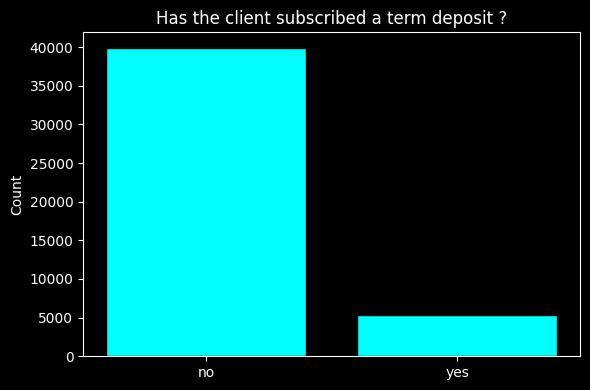



y
no     88.30152
yes    11.69848
Name: proportion, dtype: float64


In [11]:
plt.figure(figsize=(6, 4))
counts = train_df['y'].value_counts()

plt.bar(x = counts.index.astype(str), height=counts.values, color='cyan', edgecolor='black')


plt.title("Has the client subscribed a term deposit ?")
plt.ylabel("Count")
plt.xlabel("")

plt.tight_layout()
plt.show()

print("\n")
print(train_df["y"].value_counts(normalize=True) * 100)


### Check Feature ( Numerical - Catogorical)

In [12]:
num_col = train_df.select_dtypes(include = ["int64", "float64"]).columns
print(f"Number of this feature = {len(num_col)}")
print ("\n",num_col)

Number of this feature = 7

 Index(['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous'], dtype='object')


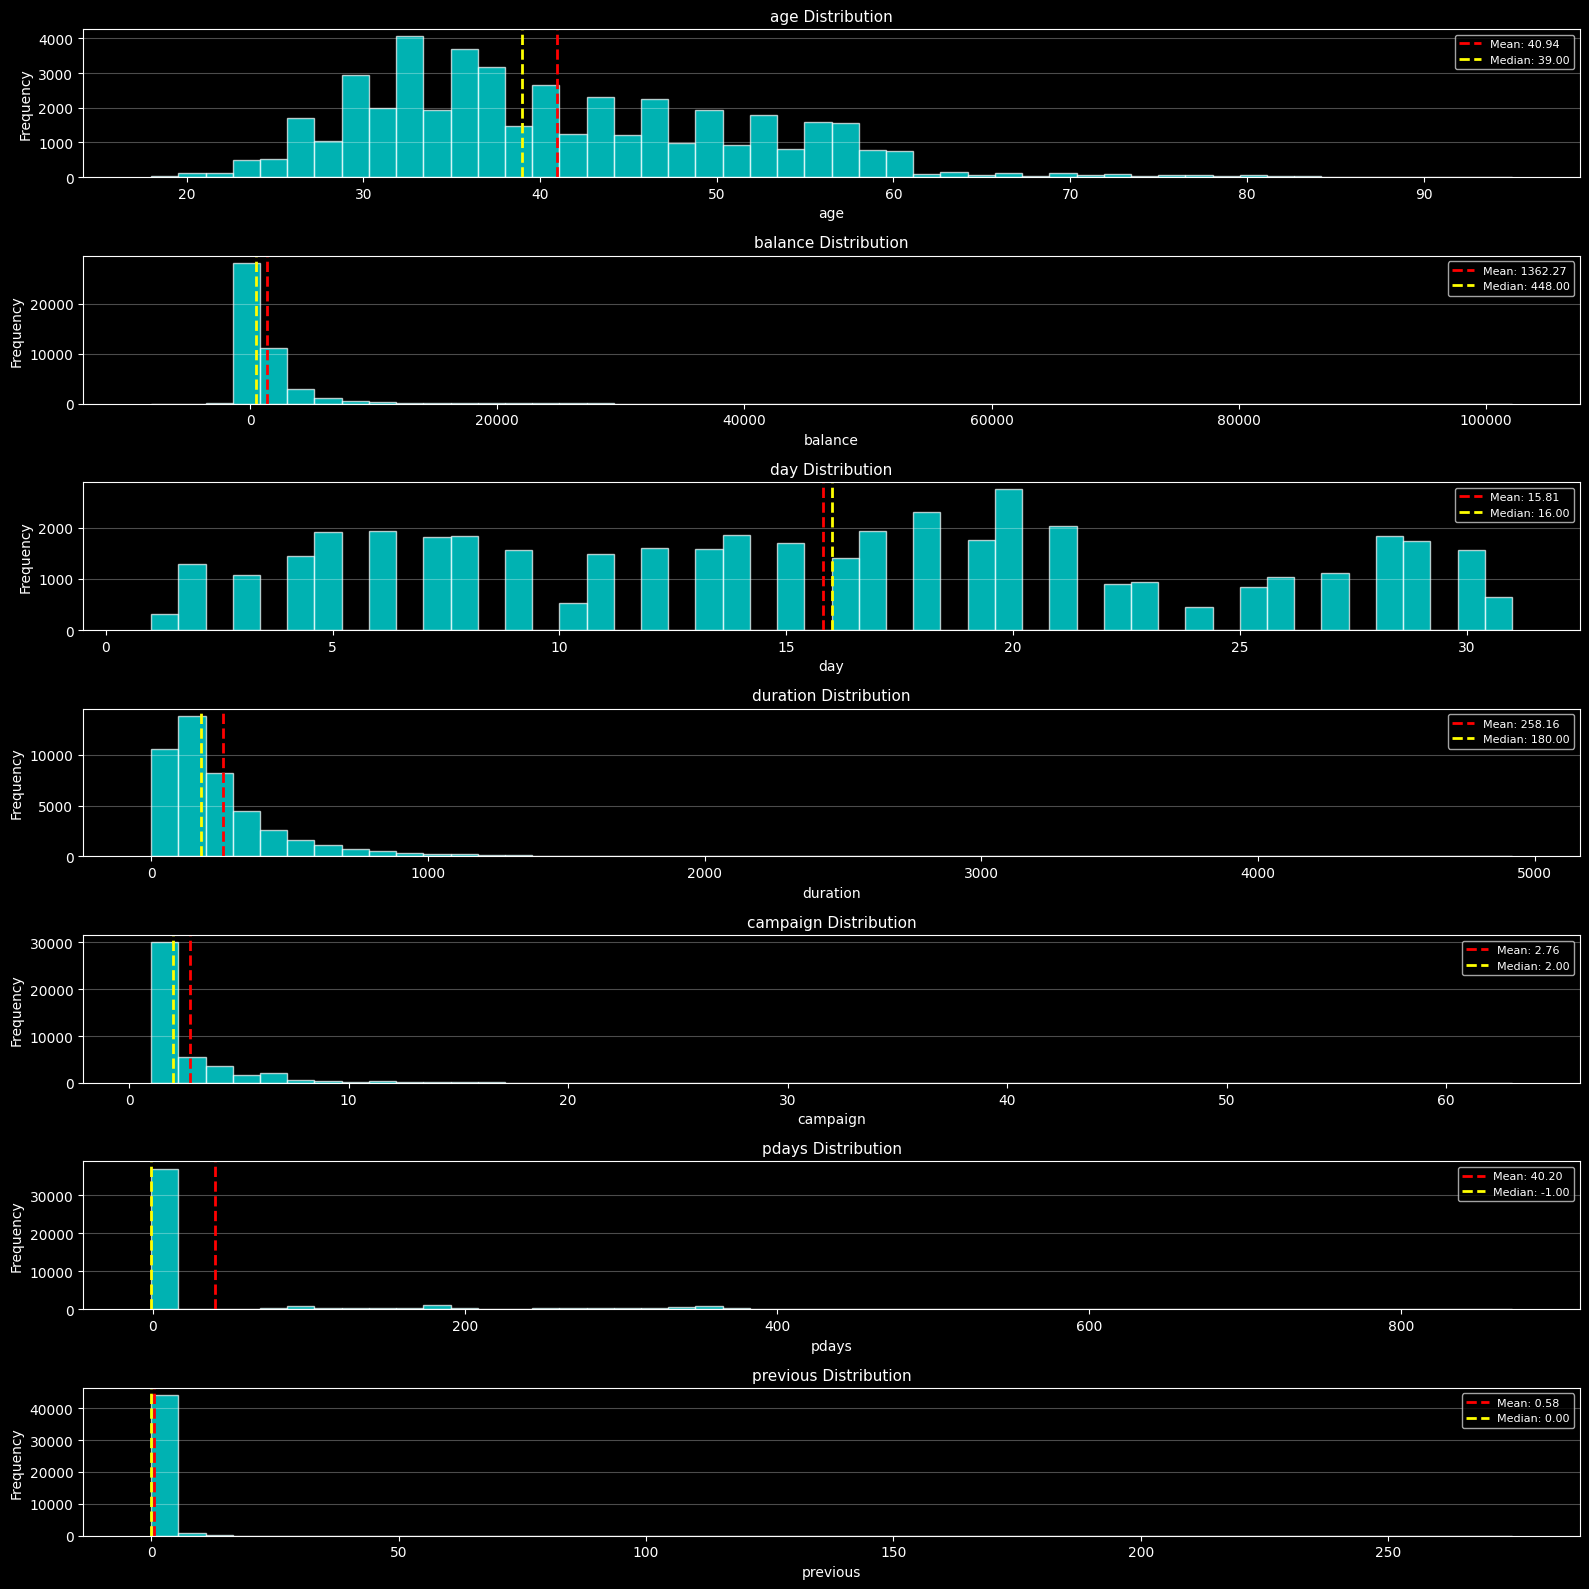

In [13]:
# Feature distributions
fig, axes = plt.subplots(7, 1, figsize=(16, 16))
axes = axes.flatten()

for i, col in enumerate(num_col):
    axes[i].hist(train_df[col], bins=50, alpha=0.7, color='cyan', edgecolor='white')
    axes[i].set_xlabel(col, fontsize=10)
    axes[i].set_ylabel('Frequency', fontsize=10)
    axes[i].set_title(f'{col} Distribution', fontsize=11)
    axes[i].grid(alpha=0.3, axis='y')

    # Add mean and median lines
    mean_val = train_df[col].mean()
    median_val = train_df[col].median()
    axes[i].axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.2f}')
    axes[i].axvline(median_val, color='yellow', linestyle='--', linewidth=2, label=f'Median: {median_val:.2f}')
    axes[i].legend(fontsize=8)


plt.tight_layout()
plt.show()


In [14]:
cat_col = train_df.select_dtypes(include = ["object"]).columns
print(f"Number of this feature = {len(cat_col)}")
print ("\n",cat_col)

Number of this feature = 10

 Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'poutcome', 'y'],
      dtype='object')


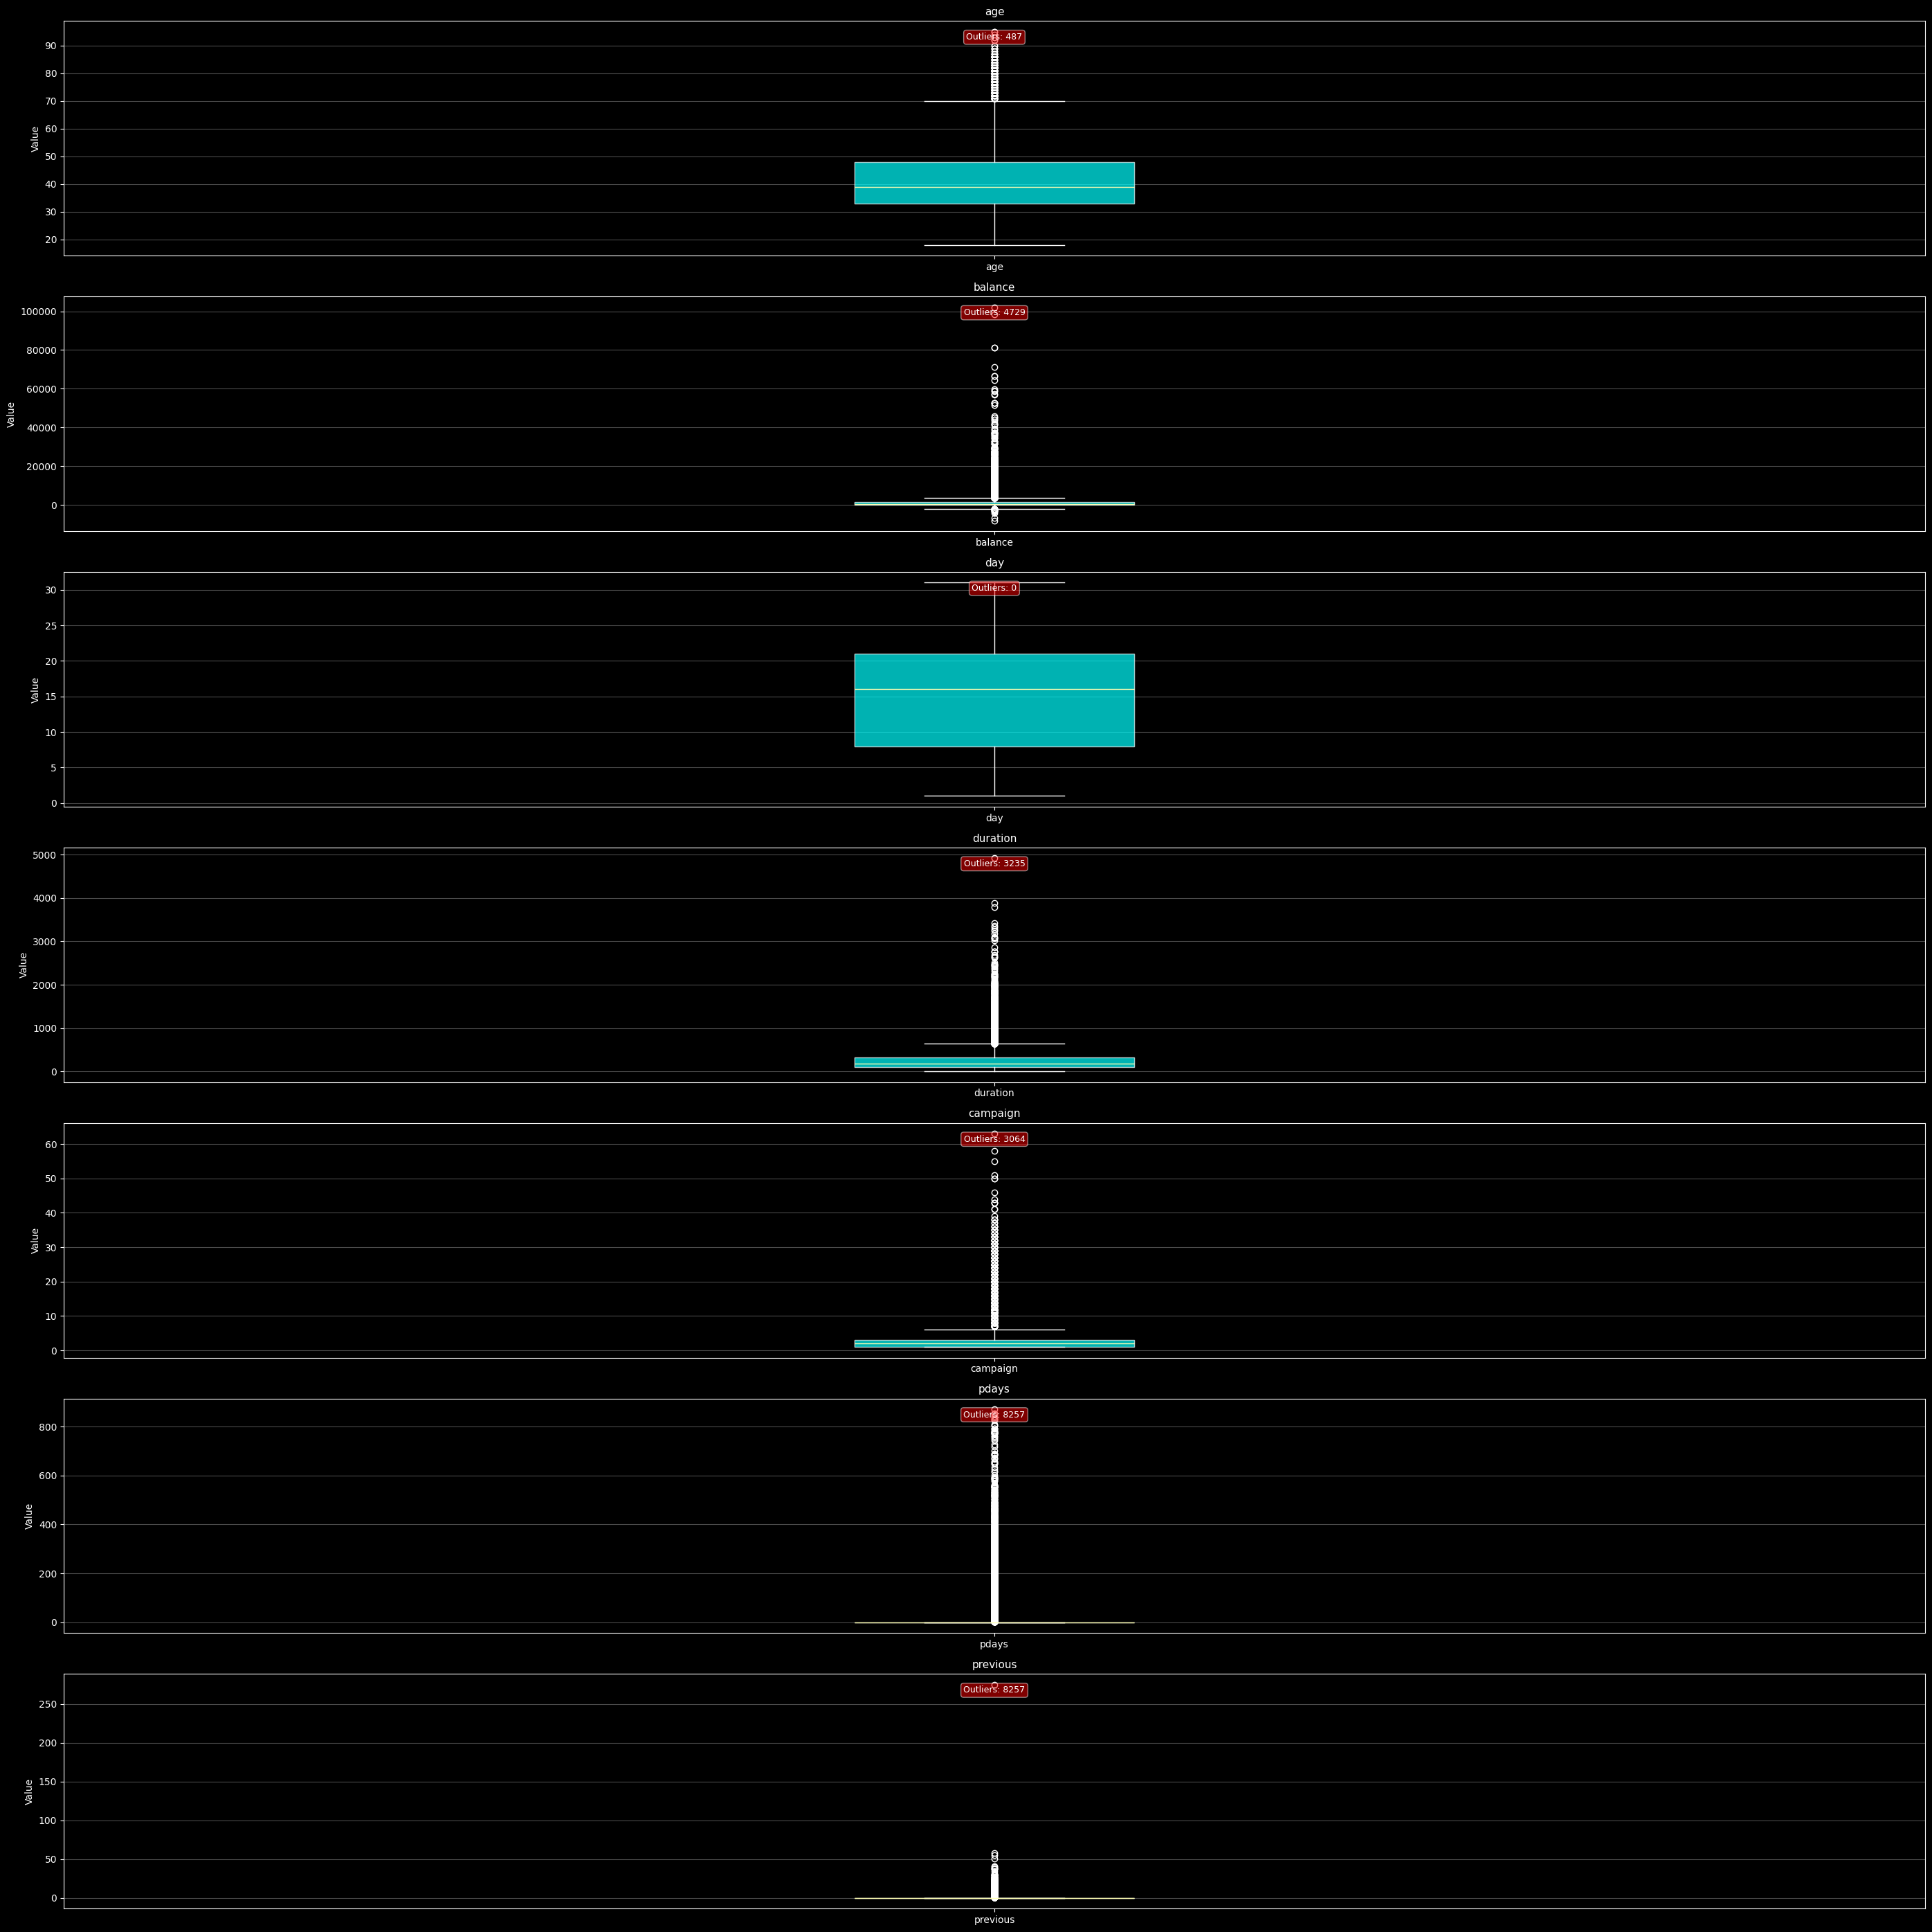

In [15]:
# Box plots for outlier detection
fig, axes = plt.subplots(7, 1, figsize=(28, 28))
axes = axes.flatten()

for i, col in enumerate(num_col):
    bp = axes[i].boxplot([train_df[col]], tick_labels=[col], patch_artist=True)
    for patch in bp['boxes']:
        patch.set_facecolor('cyan')
        patch.set_alpha(0.7)
    axes[i].set_ylabel('Value', fontsize=10)
    axes[i].set_title(f'{col}', fontsize=11)
    axes[i].grid(alpha=0.3, axis='y')

    # Count outliers
    Q1 = train_df[col].quantile(0.25)
    Q3 = train_df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = ((train_df[col] < Q1 - 1.5*IQR) | (train_df[col] > Q3 + 1.5*IQR)).sum()
    axes[i].text(0.5, 0.95, f'Outliers: {outliers}',
                 transform=axes[i].transAxes, ha='center', va='top',
                 bbox=dict(boxstyle='round', facecolor='red', alpha=0.5), fontsize=9)

plt.tight_layout()
plt.show()


### Correlation Matrix - New way for mixed type of data

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 81.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 70.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.6/155.6 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 88.6 MB/s eta 0:00:00
  Attempting uninstall: psutil
    Found existing installation: psutil 5.9.5
    Uninstalling psutil-5.9.5:
      Successfully uninstalled psutil-5.9.5
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1
  Attempting uninstall: matplotlib
    Found existing installation: matplotlib 3.10.0
    Uninstalling matplotlib-3.10.0:
      S

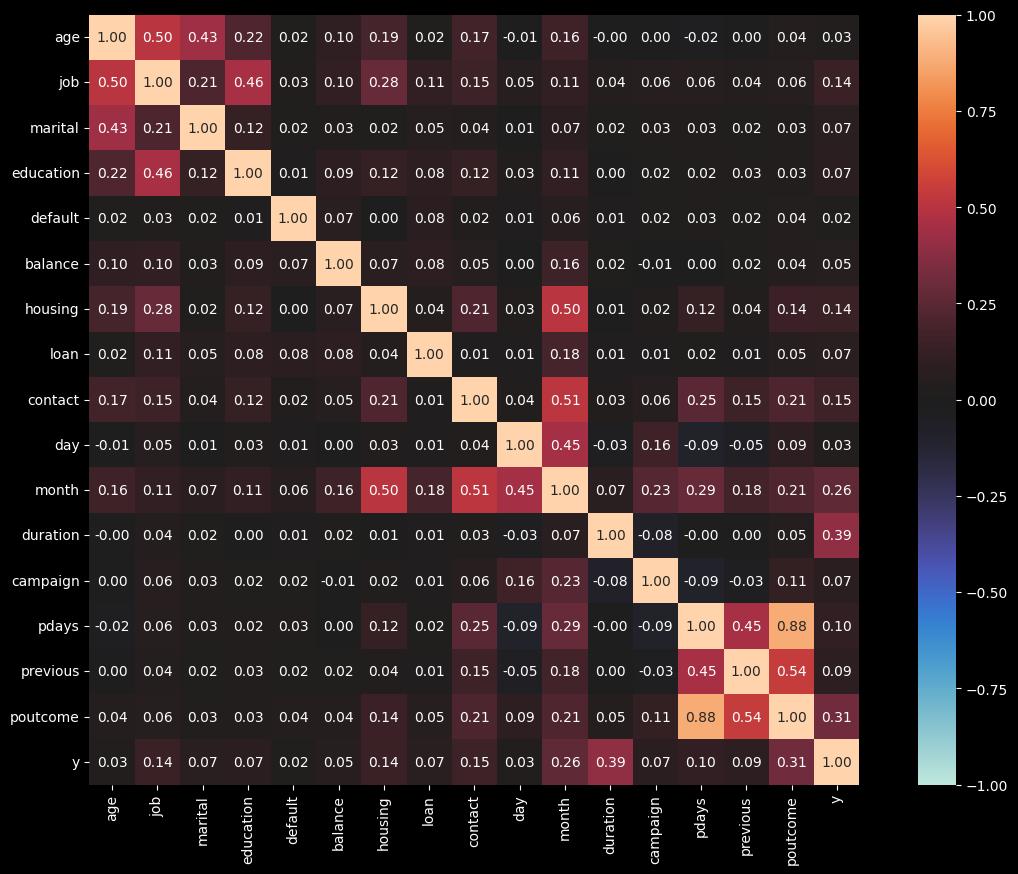

{'corr':                 age       job   marital  education   default   balance  \
 age        1.000000  0.501129  0.433431   0.215201  0.017879  0.097783   
 job        0.501129  1.000000  0.205425   0.458009  0.033036  0.101776   
 marital    0.433431  0.205425  1.000000   0.121351  0.018044  0.028172   
 education  0.215201  0.458009  0.121351   1.000000  0.013651  0.087657   
 default    0.017879  0.033036  0.018044   0.013651  1.000000  0.066745   
 balance    0.097783  0.101776  0.028172   0.087657  0.066745  1.000000   
 housing    0.185513  0.281311  0.019587   0.119062  0.003492  0.068768   
 loan       0.015655  0.105354  0.051510   0.079865  0.076865  0.084350   
 contact    0.170555  0.149658  0.044598   0.122527  0.023482  0.049317   
 day       -0.009120  0.047611  0.007723   0.025965  0.009424  0.004503   
 month      0.160218  0.109144  0.070616   0.108998  0.056564  0.155841   
 duration  -0.004648  0.040774  0.023110   0.003806  0.010021  0.021560   
 campaign   0.004

In [16]:
!pip install dython
from dython.nominal import associations

associations(train_df, figsize=(15, 10))



# 4.Data Preprocessing

### Encode Target Column

In [17]:
le_target = LabelEncoder()
train_df['y'] = le_target.fit_transform(train_df['y'])   # no -> 0 , yes -> 1
test_df['y']  = le_target.transform(test_df['y'])

print(le_target.classes_)
train_df['y'].value_counts()


['no' 'yes']


y
0    39922
1     5289
Name: count, dtype: int64

### Encoded Categorical Features

In [18]:
cat_col = train_df.select_dtypes(include=["object"]).columns

encoders = {}
for col in cat_col:
    le = LabelEncoder()
    combined = pd.concat([train_df[col], test_df[col]], axis=0)
    le.fit(combined)

    train_df[col] = le.transform(train_df[col])
    test_df[col]  = le.transform(test_df[col])

    encoders[col] = le

print(f"Encoded {len(cat_col)} categorical columns: {list(cat_col)}")
train_df.head()


Encoded 9 categorical columns: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,4,1,2,0,2143,1,0,2,5,8,261,1,-1,0,3,0
1,44,9,2,1,0,29,1,0,2,5,8,151,1,-1,0,3,0
2,33,2,1,1,0,2,1,1,2,5,8,76,1,-1,0,3,0
3,47,1,1,3,0,1506,1,0,2,5,8,92,1,-1,0,3,0
4,33,11,2,3,0,1,0,0,2,5,8,198,1,-1,0,3,0


### Scaling

In [19]:
num_col = ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

scaler = StandardScaler()
train_df[num_col] = scaler.fit_transform(train_df[num_col])
test_df[num_col]  = scaler.transform(test_df[num_col])

train_df[num_col].describe().T


,count,mean,std,min,25%,50%,75%,max
age,45211.0,2.112250e-16,1.000011,-2.159994,-0.747384,-0.182341,0.665225,5.091402
balance,45211.0,1.760208e-17,1.000011,-3.081149,-0.423772,-0.300280,0.021587,33.094776
day,45211.0,1.257292e-17,1.000011,-1.779108,-0.938003,0.023260,0.624050,1.825628
duration,45211.0,6.035001e-17,1.000011,-1.002478,-0.602517,-0.303517,0.236237,18.094700
campaign,45211.0,3.017500e-17,1.000011,-0.569351,-0.569351,-0.246560,0.076230,19.443647
pdays,45211.0,2.011667e-17,1.000011,-0.411453,-0.411453,-0.411453,-0.411453,8.297431
previous,45211.0,4.023334e-17,1.000011,-0.251940,-0.251940,-0.251940,-0.251940,119.135982


### Split Data

In [20]:
X = train_df.drop(columns=['y'])
y = train_df['y']

X_test_final = test_df.drop(columns=['y'])
y_test_final = test_df['y']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"X_train: {X_train.shape}, X_val: {X_val.shape}, X_test_final: {X_test_final.shape}")


X_train: (36168, 16), X_val: (9043, 16), X_test_final: (4521, 16)


# Build Deep Neural Network

### Parameters

In [21]:
batch_size = 128
hidden_units = 256
dropout = 0.45

### Model

In [22]:
model = Sequential()

model.add(Dense(hidden_units, input_dim = X_train.shape[1]))
model.add(Activation('relu'))
model.add(Dropout(dropout))


model.add(Dense(hidden_units))
model.add(Activation('relu'))
model.add(Dropout(dropout))


model.add(Dense(1, activation="sigmoid"))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-08-13 21:51:46.352053: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


### Summary

In [23]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 70,401 (275.00 KB)

 Trainable params: 70,401 (275.00 KB)

 Non-trainable params: 0 (0.00 B)

### Visualizaion

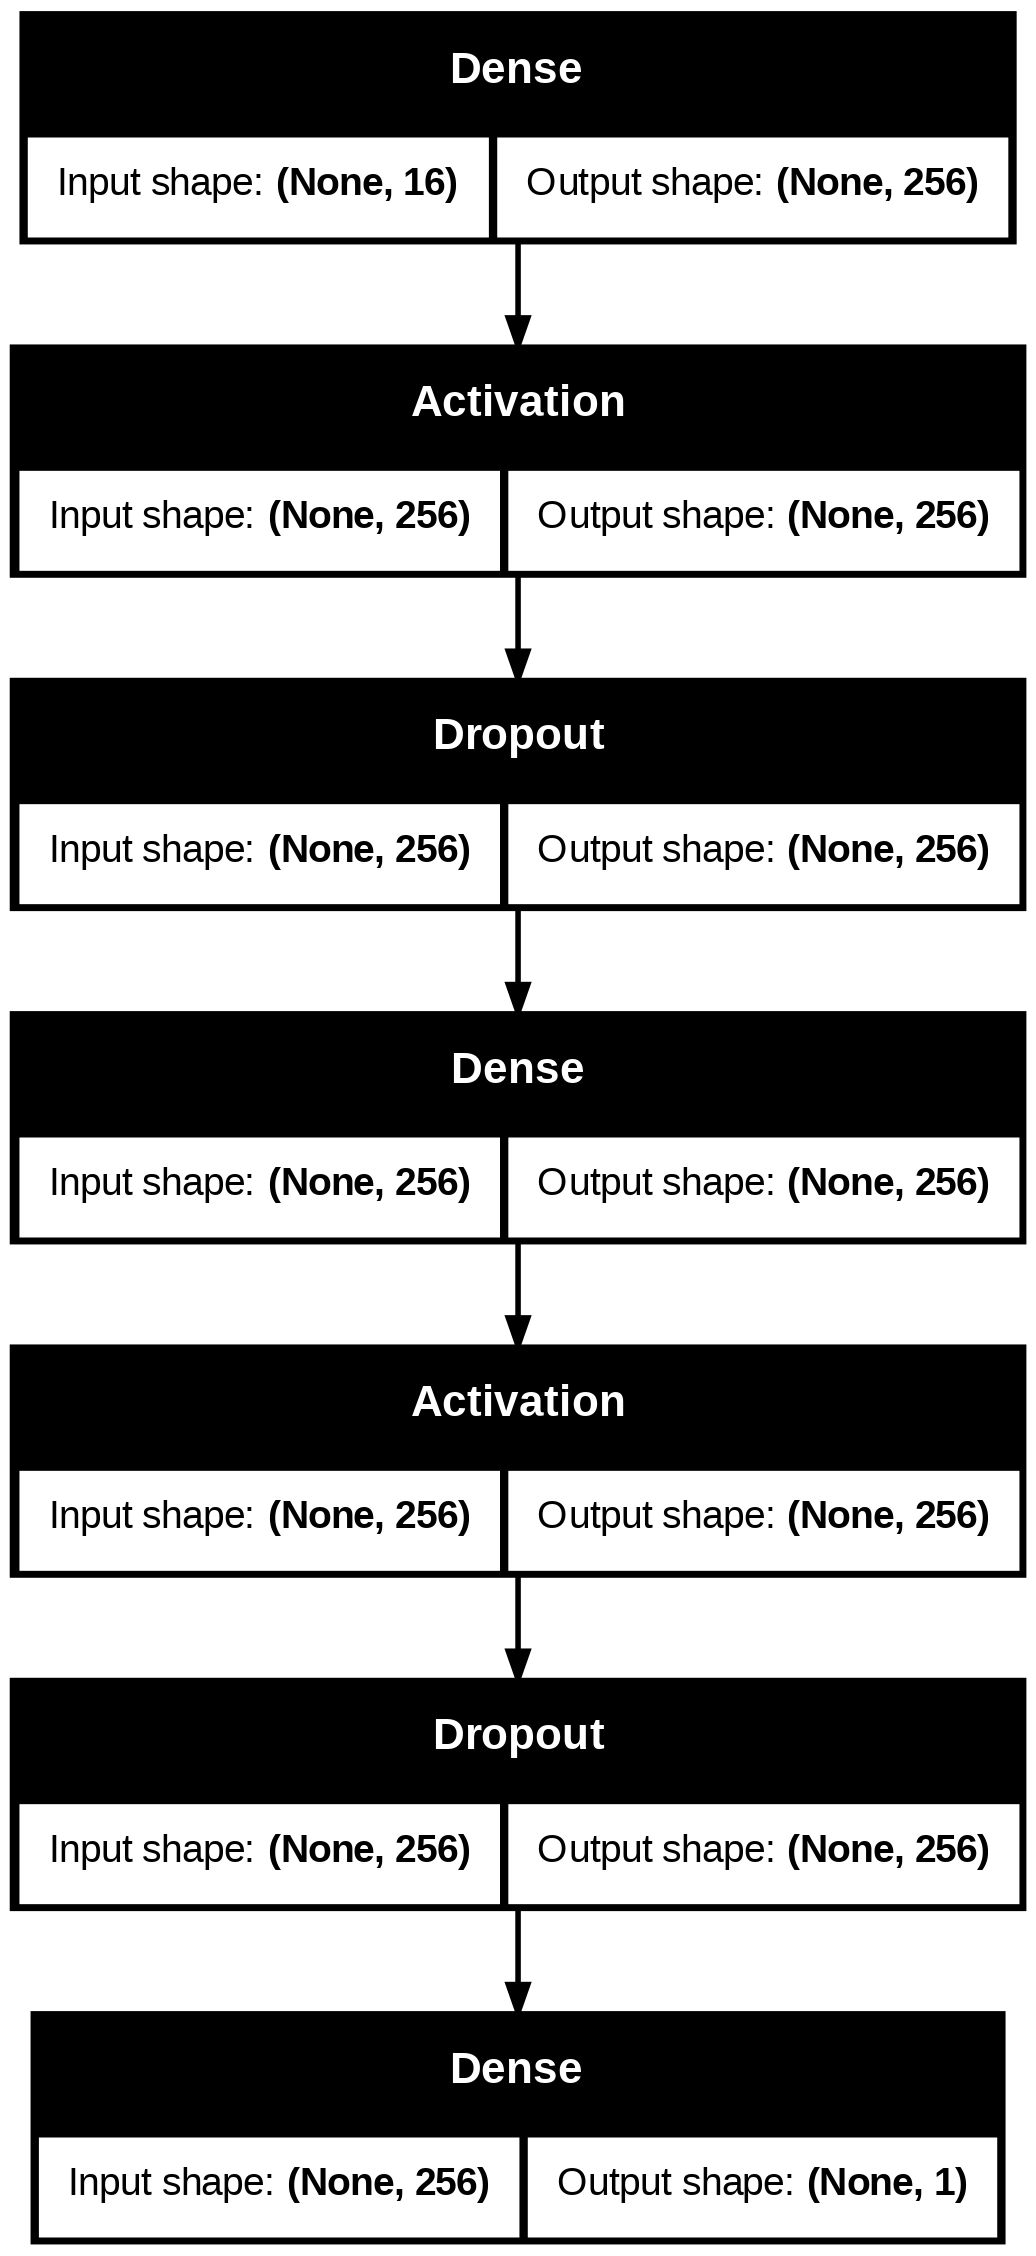

In [24]:
plot_model(model, show_shapes=True)

### Compiling

In [25]:
import tensorflow as tf

model.compile(optimizer="adam",loss="binary_crossentropy",metrics=["accuracy",tf.keras.metrics.AUC(name='auc')])

### Training Model

In [26]:
from sklearn.utils.class_weight import compute_class_weight
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(enumerate(class_weights))
print(f"Class weights: {class_weight_dict}")

early_stop = EarlyStopping(monitor='val_auc', mode='max', patience=10, restore_best_weights=True)
reduce_lr  = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)

history = model.fit(X_train, y_train,validation_data=(X_val, y_val),epochs=100,batch_size=128,class_weight=class_weight_dict,
                    callbacks=[early_stop, reduce_lr],verbose=1)

Class weights: {0: np.float64(0.5662397845758838), 1: np.float64(4.27416686362562)}
Epoch 1/100
283/283 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.7519 - auc: 0.8315 - loss: 0.5101 - val_accuracy: 0.8169 - val_auc: 0.8839 - val_loss: 0.3993 - learning_rate: 0.0010
Epoch 2/100
283/283 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7835 - auc: 0.8779 - loss: 0.4383 - val_accuracy: 0.8255 - val_auc: 0.8904 - val_loss: 0.3598 - learning_rate: 0.0010
Epoch 3/100
283/283 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7859 - auc: 0.8848 - loss: 0.4254 - val_accuracy: 0.8176 - val_auc: 0.8941 - val_loss: 0.3690 - learning_rate: 0.0010
Epoch 4/100
283/283 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7908 - auc: 0.8895 - loss: 0.4170 - val_accuracy: 0.8167 - val_auc: 0.8968 - val_loss: 0.3733 - learning_rate: 0.0010
Epoch 5/100
283/283 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7946 - auc: 0.8925 - loss: 0.4119 - val_accuracy: 0.8074 - val_auc: 0.8980 - val_loss: 0.3863 - learning_rate

### Training Visualization

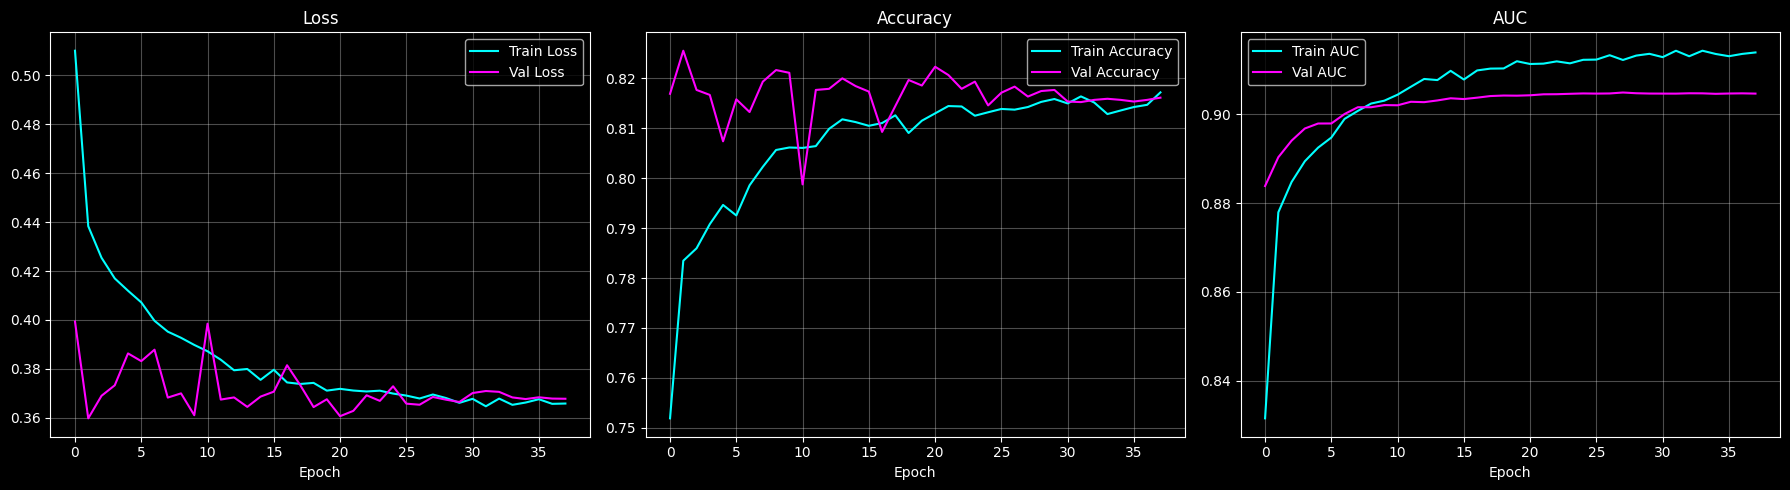

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(history.history['loss'], label='Train Loss', color='cyan')
axes[0].plot(history.history['val_loss'], label='Val Loss', color='magenta')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history.history['accuracy'], label='Train Accuracy', color='cyan')
axes[1].plot(history.history['val_accuracy'], label='Val Accuracy', color='magenta')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(alpha=0.3)

axes[2].plot(history.history['auc'], label='Train AUC', color='cyan')
axes[2].plot(history.history['val_auc'], label='Val AUC', color='magenta')
axes[2].set_title('AUC')
axes[2].set_xlabel('Epoch')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()


### Evaluate Model

In [28]:
y_pred_proba = model.predict(X_test_final).ravel()
y_pred = (y_pred_proba >= 0.5).astype(int)

acc = accuracy_score(y_test_final, y_pred)
f1  = f1_score(y_test_final, y_pred)
auc = roc_auc_score(y_test_final, y_pred_proba)

print(f"Accuracy : {acc:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"ROC-AUC  : {auc:.4f}")
print("\n", classification_report(y_test_final, y_pred, target_names=le_target.classes_))

142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Accuracy : 0.8093
F1-score : 0.5113
ROC-AUC  : 0.9074

               precision    recall  f1-score   support

          no       0.98      0.80      0.88      4000
         yes       0.36      0.87      0.51       521

    accuracy                           0.81      4521
   macro avg       0.67      0.83      0.70      4521
weighted avg       0.91      0.81      0.84      4521



### Confusion Matrix

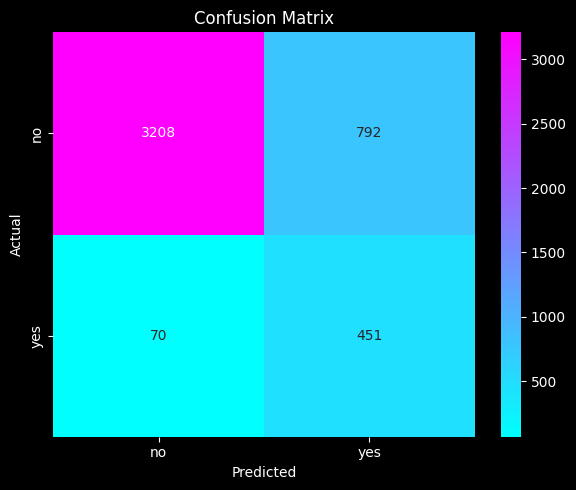

In [29]:
cm = confusion_matrix(y_test_final, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='cool',
            xticklabels=le_target.classes_, yticklabels=le_target.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()


### Roc Curve

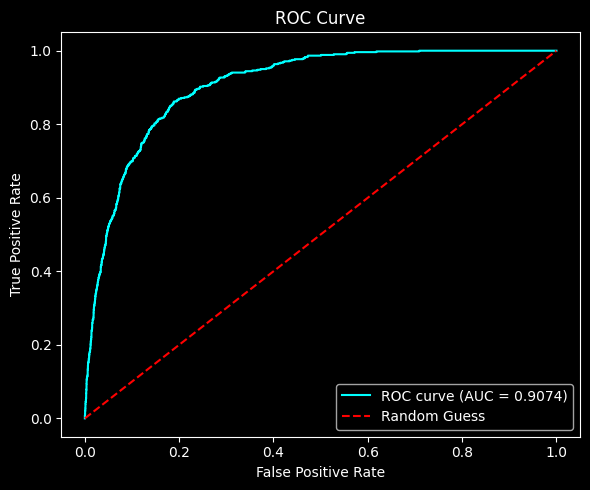

In [30]:
fpr, tpr, thresholds = roc_curve(y_test_final, y_pred_proba)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='cyan', label=f'ROC curve (AUC = {auc:.4f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.tight_layout()
plt.show()
